# Offline Preprocessing Starter (Python)

This notebook is the fully independent Python version of `offline_preprocessing_starter.m`. It shows a minimal offline EEG workflow on one example `.gdf` file:

- find the project and dataset
- open one offline run
- keep EEG channels and separate the auxiliary eye channels
- bandpass filter and regress out EOG
- make quick sanity-check plots
- build the task spectrogram using the same style as the MATLAB starter
- compute grand-average topoplots across all subjects for each task condition

The code is intentionally short, and each section explains what it is doing.


In [1]:
from pathlib import Path
import os

cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == 'starter' else cwd
DATASET_ROOT = next((REPO_ROOT / name for name in ['BCI_Harmony_ExperimentalData', 'BCI_course_EXP'] if (REPO_ROOT / name).exists()), None)
assert DATASET_ROOT is not None, 'Could not find the dataset folder.'

os.environ.setdefault('MPLCONFIGDIR', str(REPO_ROOT / '.matplotlib'))

import matplotlib.pyplot as plt
import mne
import numpy as np
from scipy.signal import butter, filtfilt, spectrogram, welch

plt.rcParams['figure.dpi'] = 150

def bandpass(data, fs, low_hz, high_hz, order=2):
    b, a = butter(order, [low_hz, high_hz], btype='bandpass', fs=fs)
    return filtfilt(b, a, data, axis=0)

def get_event_table(raw):
    event_samples = np.rint(raw.annotations.onset * raw.info['sfreq']).astype(int)
    event_codes = np.array([int(desc) for desc in raw.annotations.description], dtype=int)
    return event_samples, event_codes

print('Repo root :', REPO_ROOT)
print('Dataset   :', DATASET_ROOT)

Matplotlib is building the font cache; this may take a moment.


Repo root : /Users/kanishkamitra/Documents/UT/BMI_Harmony/bci_exo_startstop_ICRA_26
Dataset   : /Users/kanishkamitra/Documents/UT/BMI_Harmony/bci_exo_startstop_ICRA_26/BCI_Harmony_ExperimentalData


## 1) Choose one offline file

We keep this simple: just grab the first offline `.gdf` file in sorted order. That makes the notebook reproducible, but you can change `target_file` if you want to inspect a different run.

In [2]:
gdf_files = sorted((DATASET_ROOT / 'offline_data').glob('Sub_*/*offline*/*.gdf'))
assert gdf_files, 'No offline .gdf files found.'

target_file = gdf_files[0]
raw = mne.io.read_raw_gdf(target_file, preload=True, verbose='ERROR')
signal = raw.get_data().T
fs = float(raw.info['sfreq'])
chan_labels = np.array(raw.ch_names, dtype=str)
event_samples, event_codes = get_event_table(raw)

print(f'Loading: {target_file}')
print(f'Samples: {signal.shape[0]} | Channels: {signal.shape[1]} | Fs: {fs:.2f} Hz')
print('Unique trigger labels:', sorted(np.unique(event_codes).tolist()))
chan_labels[:10]

Loading: /Users/kanishkamitra/Documents/UT/BMI_Harmony/bci_exo_startstop_ICRA_26/BCI_Harmony_ExperimentalData/offline_data/Sub_1/Sub_1_run_1_10172023_1801_offline/Sub_1_run_1_offline.gdf
Samples: 210432 | Channels: 68 | Fs: 512.00 Hz
Unique trigger labels: [100, 150, 300, 500, 550, 900, 950, 1000, 2000]


array(['FP1', 'FPZ', 'FP2', 'F7', 'F3', 'FZ', 'F4', 'F8', 'FC5', 'FC1'],
      dtype='<U6')

## 2) Keep EEG channels and clean them

Here we split the data into EEG and auxiliary channels. In this dataset, the first 64 channels are EEG, the last three sensor channels (`sens7-9`) are the eye channels, and `Status` carries trigger information.

Then we do a very standard light preprocessing pass:

- remove a couple of frontal channels if you do not want them
- bandpass the EEG from 8 to 30 Hz
- regress out the eye channels

This is meant to stay small and readable, not be a full preprocessing pipeline.

In [3]:
labels_upper = np.char.upper(chan_labels)
manual_remove = np.array(['FP1', 'FP2'])
manual_mask = np.isin(labels_upper, manual_remove)
eog_mask = np.isin(np.arange(signal.shape[1]), [64, 65, 66]) | np.char.startswith(labels_upper, 'SENS')
status_mask = labels_upper == 'STATUS'
eeg_mask = ~(manual_mask | eog_mask | status_mask)

eeg_raw = signal[:, eeg_mask]
eeg_labels = chan_labels[eeg_mask]
eog = signal[:, eog_mask]
eog_labels = chan_labels[eog_mask]

eeg_bp = bandpass(eeg_raw, fs, 8.0, 30.0)
if eog.shape[1]:
    eog_bp = bandpass(eog, fs, 8.0, 30.0)
    beta, *_ = np.linalg.lstsq(eog_bp, eeg_bp, rcond=None)
    eeg_clean = eeg_bp - eog_bp @ beta
else:
    eeg_clean = eeg_bp.copy()

print('EEG channels kept:', eeg_clean.shape[1])
print('EOG channels used:', list(eog_labels))
print('First few EEG labels:', eeg_labels[:10].tolist())

EEG channels kept: 62
EOG channels used: [np.str_('sens7'), np.str_('sens8'), np.str_('sens9')]
First few EEG labels: ['FPZ', 'F7', 'F3', 'FZ', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6']


## 3) Quick sanity-check plots

The left panel compares the average power spectrum before and after preprocessing. The right panel gives a simple time-frequency view of one cleaned EEG channel.

By default we try to show `C3`; if it is missing, we just plot the first kept channel.

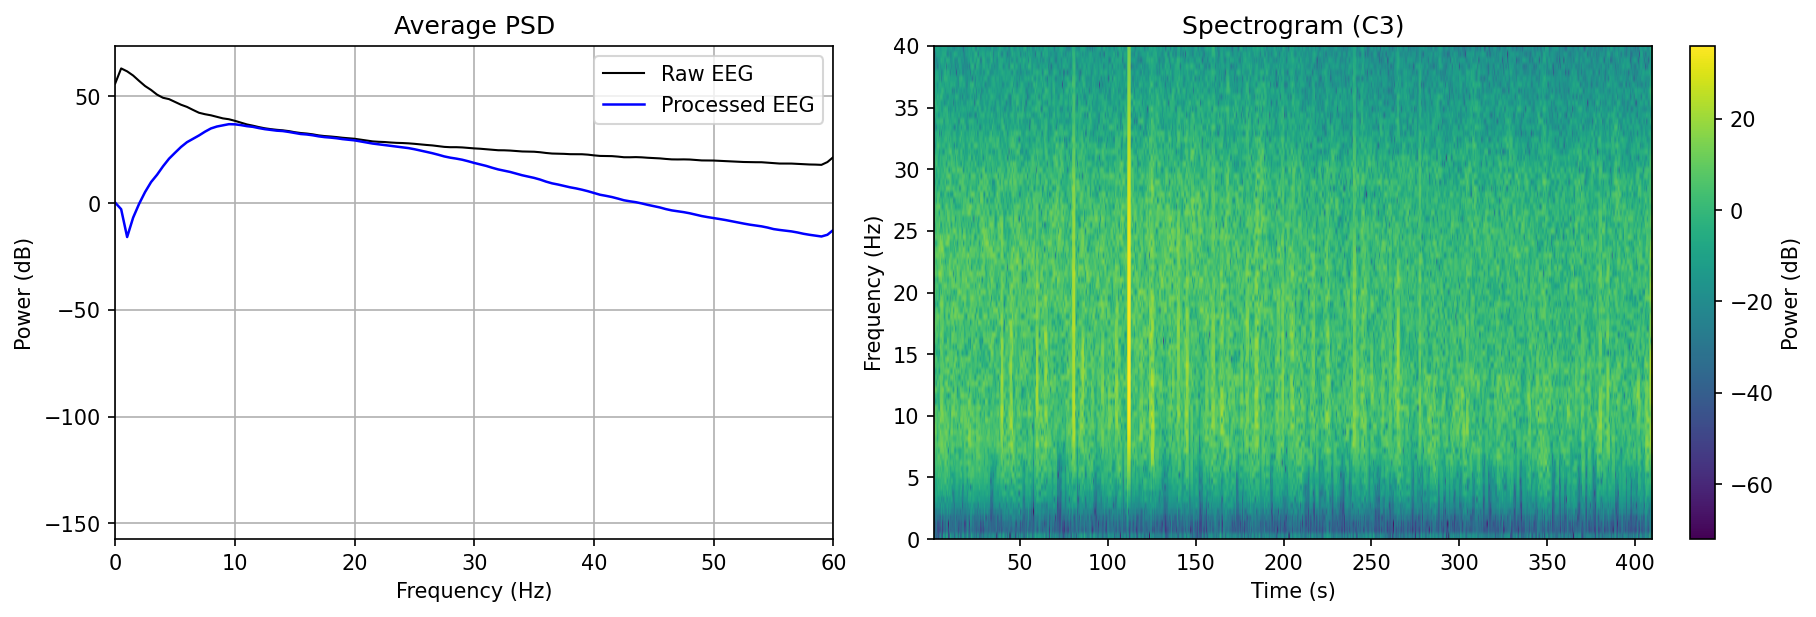

In [4]:
freq_psd, pxx_raw = welch(eeg_raw, fs=fs, nperseg=int(2 * fs), axis=0)
_, pxx_clean = welch(eeg_clean, fs=fs, nperseg=int(2 * fs), axis=0)

ch_plot = np.where(np.char.upper(eeg_labels) == 'C3')[0]
ch_plot = int(ch_plot[0]) if ch_plot.size else 0

freq_tf, time_tf, spec_tf = spectrogram(
    eeg_clean[:, ch_plot],
    fs=fs,
    nperseg=int(2 * fs),
    noverlap=int(1.5 * fs),
    nfft=int(2 * fs),
)
freq_mask = freq_tf <= 40

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(freq_psd, 10 * np.log10(np.mean(pxx_raw, axis=1) + np.finfo(float).eps), color='k', lw=1, label='Raw EEG')
axes[0].plot(freq_psd, 10 * np.log10(np.mean(pxx_clean, axis=1) + np.finfo(float).eps), color='b', lw=1.2, label='Processed EEG')
axes[0].set_xlim(0, 60)
axes[0].grid(True)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Power (dB)')
axes[0].set_title('Average PSD')
axes[0].legend(loc='upper right')

im = axes[1].imshow(
    10 * np.log10(spec_tf[freq_mask] + np.finfo(float).eps),
    aspect='auto',
    origin='lower',
    extent=[time_tf[0], time_tf[-1], freq_tf[freq_mask][0], freq_tf[freq_mask][-1]],
    cmap='viridis',
)
axes[1].set_ylim(0, 40)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_title(f'Spectrogram ({eeg_labels[ch_plot]})')
fig.colorbar(im, ax=axes[1], label='Power (dB)')
plt.show()

## 4) Task spectrogram in the same style as the MATLAB starter

This block mirrors the MATLAB task-spectrogram cell:

- use the first 64 channels as EEG
- use channels 65:67 as EOG regressors
- bandpass from 0.1 to 45 Hz
- keep the same reduced 22-channel montage
- apply common average reference
- align trials to trigger `300`
- compute baseline-normalized Welch PSD
- plot the result with the same event markers

Change `spectrogram_channel` if you want a different channel from the reduced montage.

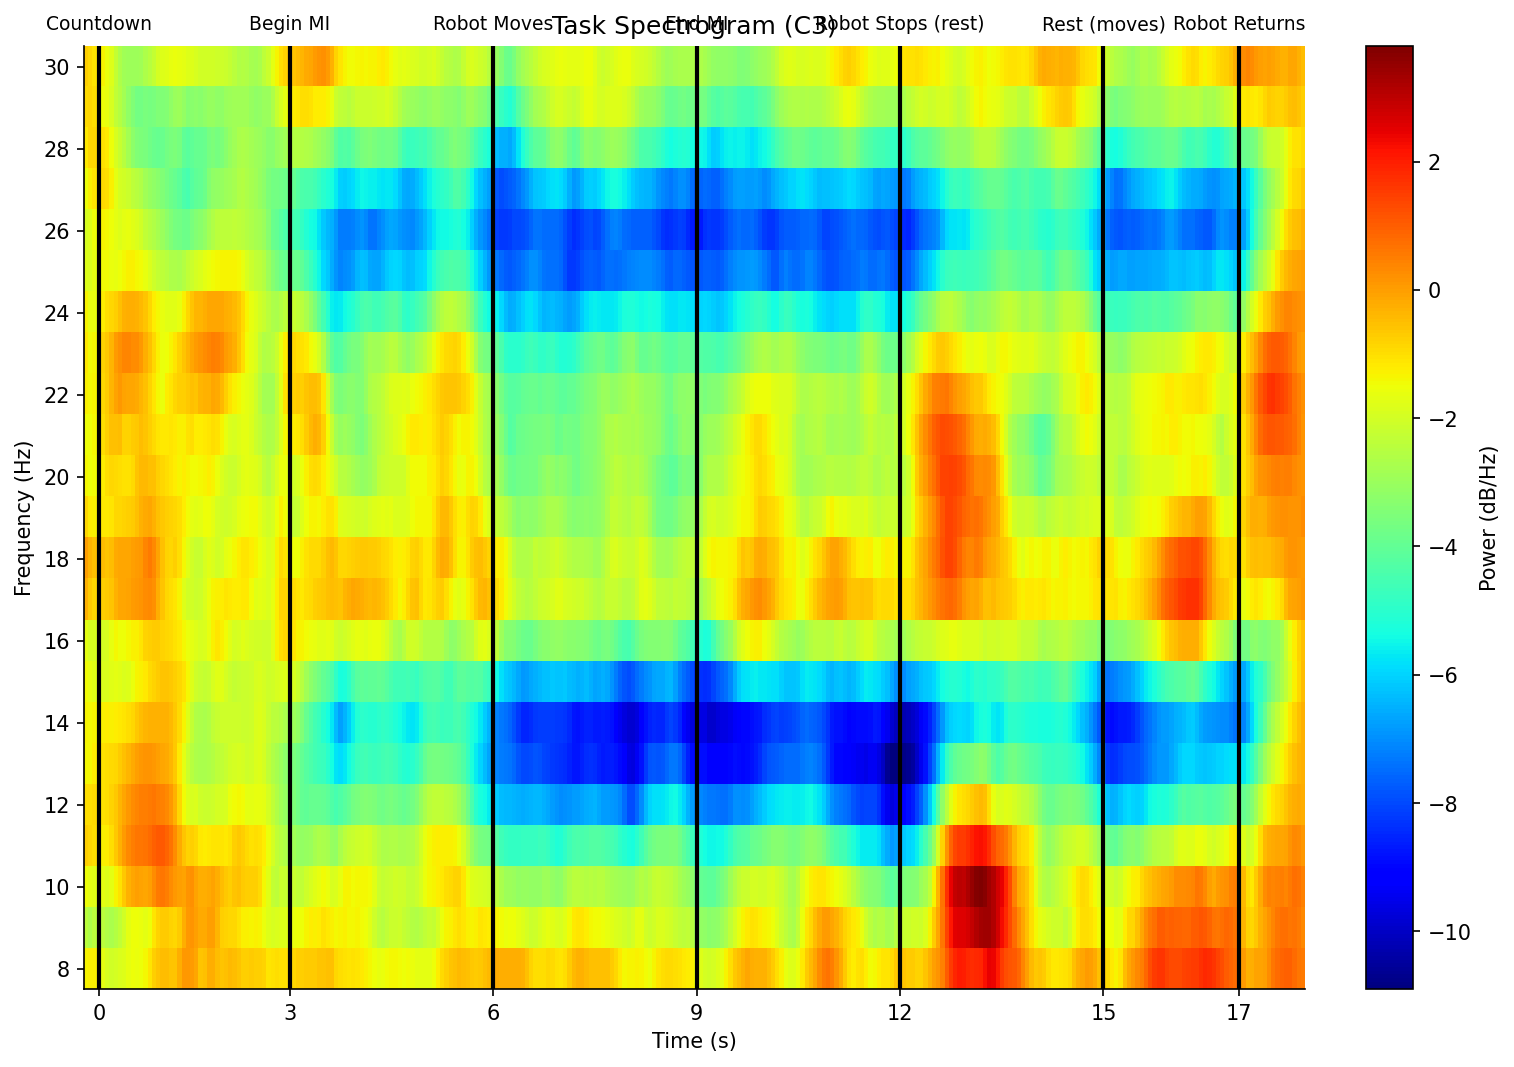

In [5]:
spectrogram_channel = 'C3'
spec_keep_idx = np.r_[4:13, 15:18, 20:30] - 1
spec_data = signal[:event_samples[-1], :]
spec_eeg = spec_data[:, :64]
spec_eog = spec_data[:, 64:67]
spec_labels = chan_labels[:64][spec_keep_idx]
spec_ch_idx = np.where(np.char.upper(spec_labels) == spectrogram_channel.upper())[0]
assert spec_ch_idx.size, 'Requested spectrogram channel was not found.'
spec_ch_idx = int(spec_ch_idx[0])

spec_eeg = bandpass(spec_eeg, fs, 0.1, 45.0)
if spec_eog.shape[1]:
    spec_eog = bandpass(spec_eog, fs, 0.1, 45.0)
    spec_beta, *_ = np.linalg.lstsq(spec_eog, spec_eeg, rcond=None)
    spec_eeg = spec_eeg - spec_eog @ spec_beta

spec_eeg = spec_eeg[:, spec_keep_idx]
spec_eeg = spec_eeg - spec_eeg.mean(axis=1, keepdims=True)

countdown_pos = event_samples[event_codes == 300]
countdown_pos = countdown_pos[(countdown_pos - 2 * fs >= 0) & (countdown_pos + 18 * fs <= spec_eeg.shape[0])]
assert countdown_pos.size, 'No valid countdown triggers were found for spectrogram trials.'

window_size = 1.0
baseline_window_size = 2.0
step_size = 0.0625
step_samples = int(round(step_size * fs))
num_windows = int(round(1 / step_size))
num_trial_windows = int(round(18 / step_size))
num_baseline_windows = int(round((baseline_window_size - window_size) / step_size + 1))
freq_keep = np.arange(8, 31)

epochs_freq = np.zeros((freq_keep.size, num_trial_windows, countdown_pos.size))
baseline_epochs_freq = np.zeros((freq_keep.size, num_baseline_windows, countdown_pos.size))

for trial_idx, start in enumerate(countdown_pos.astype(int)):
    curr = start
    for win_idx in range(num_trial_windows):
        freq_axis, pxx = welch(
            spec_eeg[curr:curr + int(fs), spec_ch_idx],
            fs=fs,
            window='hamming',
            nperseg=int(0.5 * fs),
            noverlap=int(round(0.4 * fs)),
            nfft=int(fs),
        )
        epochs_freq[:, win_idx, trial_idx] = pxx[(freq_axis >= 8) & (freq_axis <= 30)]
        curr += step_samples

    curr = start - int(2 * fs)
    for win_idx in range(num_baseline_windows):
        freq_axis, pxx = welch(
            spec_eeg[curr:curr + int(fs), spec_ch_idx],
            fs=fs,
            window='hamming',
            nperseg=int(0.5 * fs),
            noverlap=int(round(0.4 * fs)),
            nfft=int(fs),
        )
        baseline_epochs_freq[:, win_idx, trial_idx] = pxx[(freq_axis >= 8) & (freq_axis <= 30)]
        curr += step_samples

baseline_mean = baseline_epochs_freq.mean(axis=1)
epochs_freq_bld = epochs_freq / baseline_mean[:, None, :]
PSD_matrix = np.flipud(10 * np.log10(epochs_freq_bld).mean(axis=2))
freq_plot = freq_keep[::-1]

event_x = np.rint(np.array([0.2, 3.0, 6.0, 9.0, 12.0, 15.0, 17.0]) * num_windows).astype(int)
event_labels = ['Countdown', 'Begin MI', 'Robot Moves', 'End MI', 'Robot Stops (rest)', 'Rest (moves)', 'Robot Returns']

fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
im = ax.imshow(PSD_matrix, aspect='auto', cmap='jet', origin='upper')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Power (dB/Hz)')

for x, label in zip(event_x, event_labels):
    ax.axvline(x, color='k', linewidth=2)
    ax.text(x, -0.8, label, ha='center', va='bottom', fontsize=9, clip_on=False)

ax.set_xticks(event_x)
ax.set_xticklabels(['0', '3', '6', '9', '12', '15', '17'])
ax.set_yticks(np.arange(0, len(freq_plot), 2))
ax.set_yticklabels(freq_plot[::2])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title(f'Task Spectrogram ({spec_labels[spec_ch_idx]})')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

## 5) Grand-average topoplots for each task condition

This block mirrors the new MATLAB topoplot cell. It uses all offline runs, averages within each subject first, and then takes the grand average across subjects.

The plotted metric is baseline-normalized sensorimotor rhythm power (`8-30 Hz`) in dB relative to the countdown segment of each trial. Negative values mean band-power suppression (ERD); positive values mean rebound (ERS).


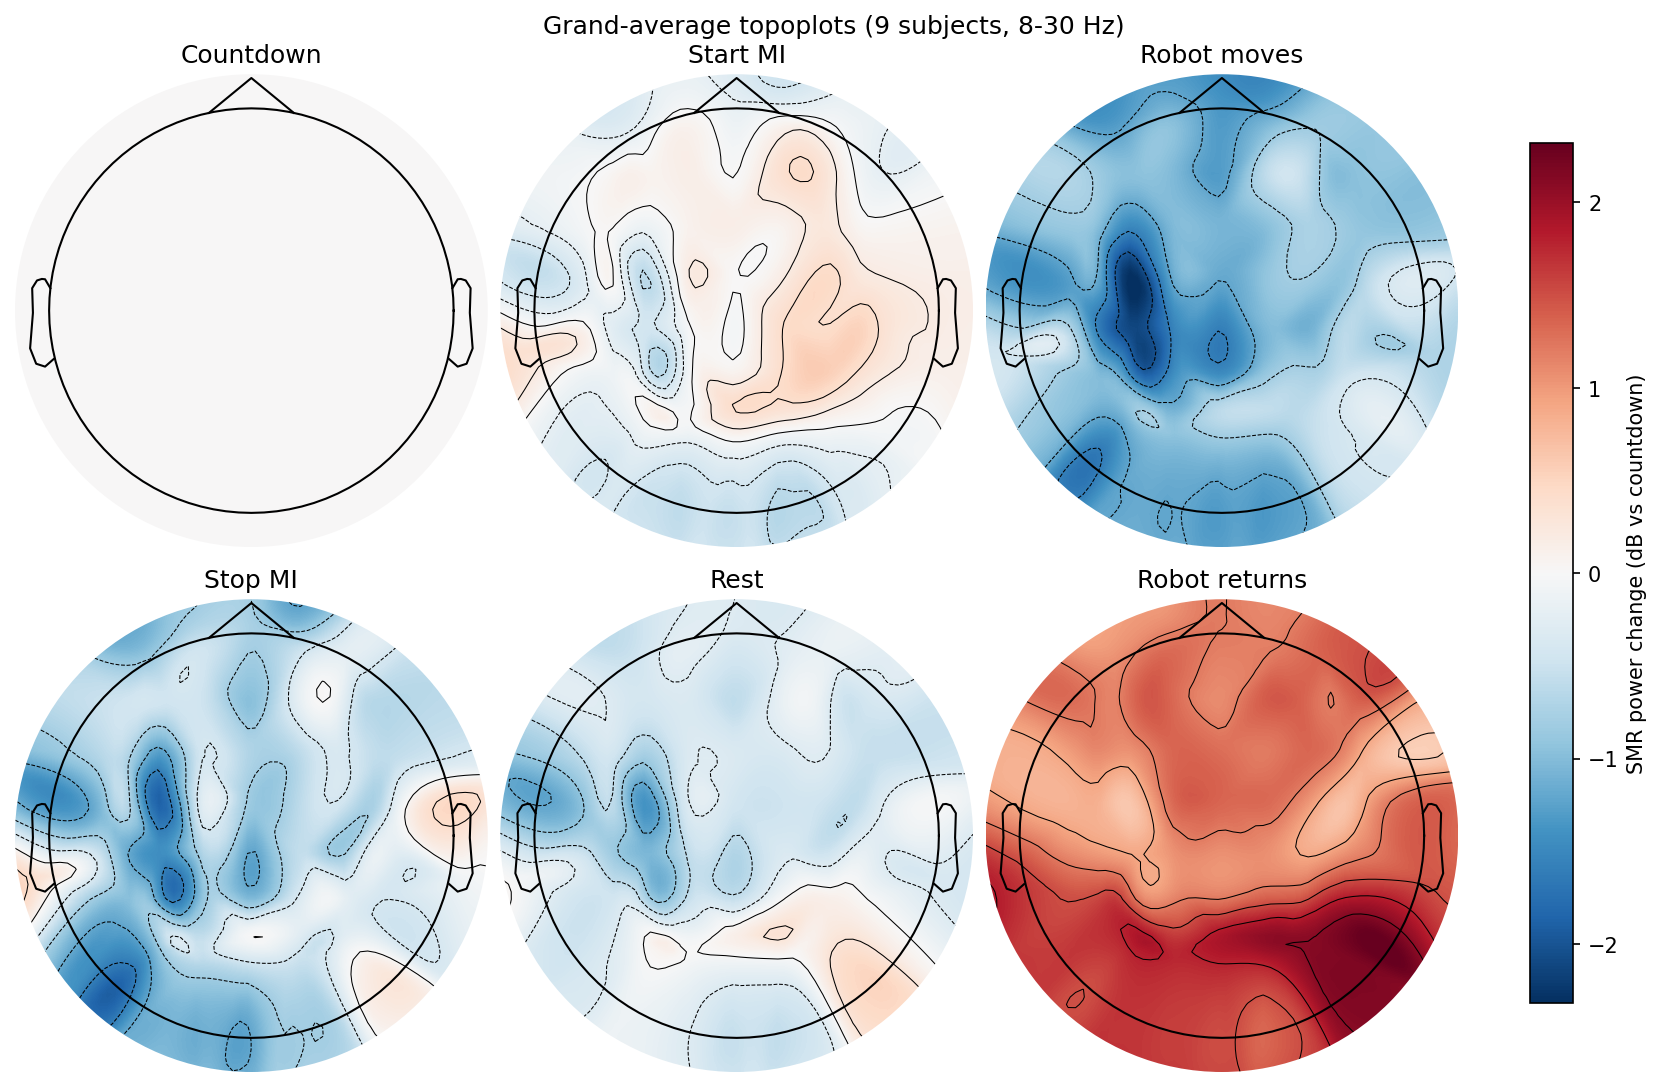

In [6]:
topo_band_hz = (8.0, 30.0)
cond_names = ['Countdown', 'Start MI', 'Robot moves', 'Stop MI', 'Rest', 'Robot returns']

montage = mne.channels.make_standard_montage('standard_1020')
standard_names = {name.upper() for name in montage.get_positions()['ch_pos']}
topo_drop = np.array([
    any(token in label for token in ['TRIG', 'STATUS', 'STI', 'MARK', 'AUX', 'EMG', 'ECG', 'EOG', 'HEOG', 'VEOG', 'SENS'])
    for label in np.char.upper(chan_labels)
])
topo_labels = np.array([lab for lab in chan_labels[~topo_drop] if lab.upper() in standard_names], dtype=str)
assert topo_labels.size, 'No scalp channels with standard positions were found.'

topo_info = mne.create_info(ch_names=topo_labels.tolist(), sfreq=fs, ch_types='eeg')
topo_info.set_montage(montage, match_case=False, on_missing='ignore')

subject_dirs = sorted((DATASET_ROOT / 'offline_data').glob('Sub_*'))
subject_maps = np.full((topo_labels.size, len(cond_names), len(subject_dirs)), np.nan)

for subject_idx, subject_dir in enumerate(subject_dirs):
    run_files = sorted(subject_dir.glob('*offline*/*.gdf'))
    subject_sum = np.zeros((topo_labels.size, len(cond_names)))
    subject_n = 0

    for run_file in run_files:
        run_raw = mne.io.read_raw_gdf(run_file, preload=True, verbose='ERROR')
        run_signal = run_raw.get_data().T.astype(float)
        run_fs = float(run_raw.info['sfreq'])
        run_labels = np.array(run_raw.ch_names, dtype=str)
        run_labels_upper = np.char.upper(run_labels)

        topo_idx = np.array([np.where(run_labels_upper == lab.upper())[0][0] for lab in topo_labels], dtype=int)
        run_eeg = bandpass(run_signal[:, topo_idx], run_fs, 0.1, 45.0)

        run_eog_idx = np.where(np.isin(run_labels_upper, ['EOG', 'HEOG', 'VEOG']))[0]
        if run_eog_idx.size:
            run_eog = bandpass(run_signal[:, run_eog_idx], run_fs, 0.1, 45.0)
            beta, *_ = np.linalg.lstsq(run_eog, run_eeg, rcond=None)
            run_eeg = run_eeg - run_eog @ beta

        run_eeg = run_eeg - run_eeg.mean(axis=1, keepdims=True)
        run_smr = bandpass(run_eeg, run_fs, *topo_band_hz)

        run_event_samples, run_event_codes = get_event_table(run_raw)
        p300 = run_event_samples[run_event_codes == 300]
        p100 = run_event_samples[run_event_codes == 100]
        p150 = run_event_samples[run_event_codes == 150]
        p500 = run_event_samples[run_event_codes == 500]
        p550 = run_event_samples[run_event_codes == 550]
        p900 = run_event_samples[run_event_codes == 900]
        p950 = run_event_samples[run_event_codes == 950]
        p2000 = run_event_samples[run_event_codes == 2000]

        if not all(len(x) for x in [p300, p100, p150, p500, p550, p900, p950]):
            continue

        n_trials = min(len(p300), len(p100), len(p150), len(p500), len(p550), len(p900), len(p950))

        for trial_idx in range(n_trials):
            trial_end = run_smr.shape[0] - 1
            if trial_idx + 1 < len(p300):
                trial_end = min(trial_end, p300[trial_idx + 1] - 1)
            elif len(p2000):
                trial_end = min(trial_end, p2000[0] - 1)

            stop_pos = min(p550[trial_idx], p900[trial_idx])
            segments = np.array([
                [p300[trial_idx], p100[trial_idx] - 1],
                [p100[trial_idx], p150[trial_idx] - 1],
                [p150[trial_idx], p500[trial_idx] - 1],
                [p500[trial_idx], stop_pos - 1],
                [p900[trial_idx], p950[trial_idx] - 1],
                [p950[trial_idx], trial_end],
            ], dtype=int)

            if (
                np.any(segments[:, 0] < 0)
                or np.any(segments[:, 1] >= run_smr.shape[0])
                or np.any((segments[:, 1] - segments[:, 0]) < round(0.5 * run_fs))
            ):
                continue

            baseline_pow = np.mean(run_smr[segments[0, 0]:segments[0, 1] + 1] ** 2, axis=0) + np.finfo(float).eps
            cond_map = np.zeros((topo_labels.size, len(cond_names)))
            for cond_idx in range(len(cond_names)):
                seg = slice(segments[cond_idx, 0], segments[cond_idx, 1] + 1)
                cond_pow = np.mean(run_smr[seg] ** 2, axis=0) + np.finfo(float).eps
                cond_map[:, cond_idx] = 10 * np.log10(cond_pow / baseline_pow)

            subject_sum += cond_map
            subject_n += 1

    if subject_n:
        subject_maps[:, :, subject_idx] = subject_sum / subject_n

valid_subjects = np.isfinite(subject_maps).any(axis=(0, 1))
assert valid_subjects.any(), 'No valid subject maps were computed.'
grand_maps = np.nanmean(subject_maps[:, :, valid_subjects], axis=2)

fig, axes = plt.subplots(2, 3, figsize=(11, 7), constrained_layout=True)
vlim = np.nanmax(np.abs(grand_maps))

for ax, cond_name, cond_values in zip(axes.ravel(), cond_names, grand_maps.T):
    im, _ = mne.viz.plot_topomap(
        cond_values,
        topo_info,
        axes=ax,
        show=False,
        sensors=False,
        contours=6,
        cmap='RdBu_r',
        vlim=(-vlim, vlim),
    )
    ax.set_title(cond_name)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label('SMR power change (dB vs countdown)')
fig.suptitle(
    f'Grand-average topoplots ({valid_subjects.sum()} subjects, {int(topo_band_hz[0])}-{int(topo_band_hz[1])} Hz)',
    y=1.02,
)
plt.show()


## 6) What to change most often

If someone else wants to reuse this notebook, the main knobs are:

- `target_file` if they want a different offline run
- `manual_remove` if they want to drop different EEG channels
- `spectrogram_channel` if they want a channel other than `C3`
- `topo_band_hz` if they want a different frequency band for the scalp maps

Everything else is kept intentionally simple so the preprocessing steps are easy to follow.
